In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
circle_img = cv2.imread('Circle.png')
rectangle_img = cv2.imread('Rectangle.png')
triangle_img = cv2.imread('Triangle.png')
signs_img = cv2.imread('Sign.png')

In [3]:
def detect_shapes_advanced(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    result = image.copy()
    shape_name = "Неизвестно"

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 1000:
            continue

        perimeter = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * perimeter, True)

        if len(approx) == 3:
            shape_name = "Треугольник"
        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)
            aspect_ratio = w / float(h)
            if 0.9 < aspect_ratio < 1.1:
                shape_name = "Квадрат"
            else:
                shape_name = "Прямогульник"
        else:
            circularity = 4 * np.pi * area / (perimeter * perimeter)
            if circularity > 0.7:
                shape_name = "Круг"
            else:
                shape_name = f"Многоугольник ({len(approx)})"

        cv2.drawContours(result, [cnt], -1, (0, 255, 0), 2)

    print(f"Обнаруженная фигура - {shape_name}")
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

=== Окружность ===
Обнаруженная фигура - Круг


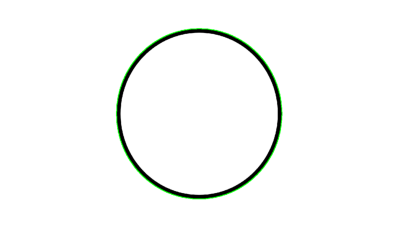

=== Прямоугольник ===
Обнаруженная фигура - Прямогульник


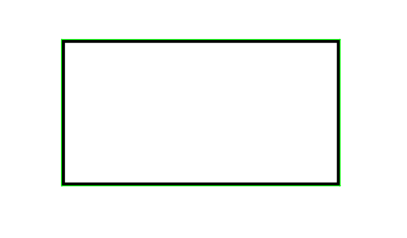

=== Треугольник ===
Обнаруженная фигура - Треугольник


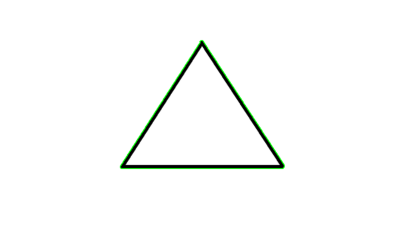

In [4]:
print("=== Окружность ===")
detect_shapes_advanced(circle_img)
print("=== Прямоугольник ===")
detect_shapes_advanced(rectangle_img)
print("=== Треугольник ===")
detect_shapes_advanced(triangle_img)

In [5]:
def detect_traffic_signs_color(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = cv2.bitwise_or(mask1, mask2)

    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    result = image.copy()
    sign_count = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 1000:
            continue

        perimeter = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * perimeter, True)
        num_vertices = len(approx)

        shape = "Неизвестно"
        is_sign = False

        if num_vertices == 3:
            shape = "Треугольник"
            is_sign = True
        elif num_vertices == 4:
            x, y, w, h = cv2.boundingRect(cnt)
            aspect = w / float(h)
            if 0.8 < aspect < 1.2:
                shape = "Квадрат"
            else:
                shape = "Прямоугольник"
            is_sign = True
        else:
            circularity = 4 * np.pi * area / (perimeter * perimeter)
            if circularity > 0.6:
                shape = "Круг"
                is_sign = True

        if is_sign:
            sign_count += 1
            cv2.drawContours(result, [cnt], -1, (0, 255, 0), 3)
            print(f"Знак - {sign_count}: {shape}, площадь = {area:.1f}")

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()



=== Дорожные знаки ===
Знак - 1: Треугольник, площадь = 49904.0


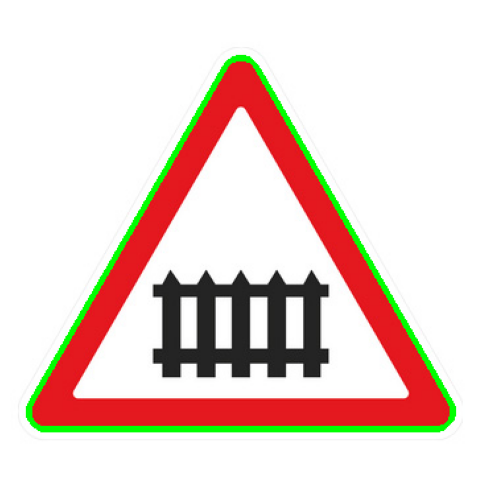

In [6]:
print("\n=== Дорожные знаки ===")
detect_traffic_signs_color(signs_img)

In [7]:
def measure_boundary_length_advanced(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5,5), 0)

    high_thresh, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    low_thresh = 0.5 * high_thresh
    edges = cv2.Canny(blurred, low_thresh, high_thresh)

    kernel = np.ones((3,3), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel, iterations=1)

    contours, _ = cv2.findContours(edges_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result = image.copy()
    total_length = 0
    boundary_data = []

    for i, cnt in enumerate(contours):
        length = cv2.arcLength(cnt, True)
        area = cv2.contourArea(cnt)
        if length < 50: 
            continue
        boundary_data.append((i+1, length, area))
        total_length += length
        cv2.drawContours(result, [cnt], -1, (0, 255, 0), 2)

    for idx, length, area in boundary_data:
        print(f"Граница - {idx}: длина = {length:.2f}, площадь = {area:.2f}")

    plt.figure(figsize=(12, 4))
    plt.subplot(1,3,1)
    plt.imshow(edges, cmap='gray')
    plt.title("Найденные границы")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(edges_dilated, cmap='gray')
    plt.title("Расширенные границы")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f"Общая длина = {total_length:.0f}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()



=== Измерение границы окружности ===
Граница - 1: длина = 1893.38, площадь = 256015.00


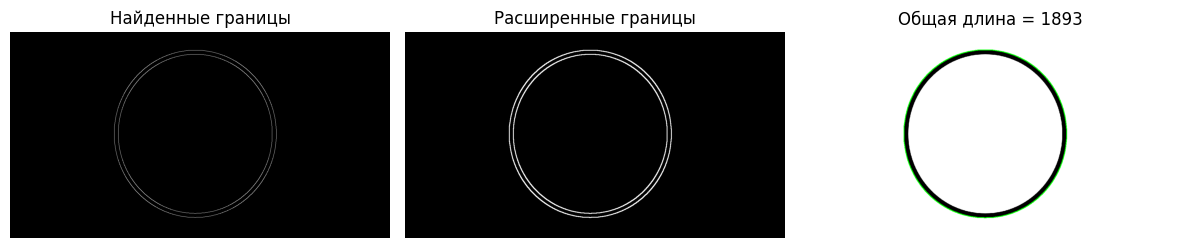

In [8]:
print("\n=== Измерение границы окружности ===")
measure_boundary_length_advanced(circle_img)